<a href="https://colab.research.google.com/github/ks-chauhan/Brain-Tumor-Detection/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [1]:
import kagglehub

path = kagglehub.dataset_download("atikaakter11/brain-tumor-segmentation-dataset")
print(path)

100%|██████████| 106M/106M [00:01<00:00, 105MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1


In [3]:
import os

base = "/root/.cache/kagglehub/datasets/atikaakter11/brain-tumor-segmentation-dataset/versions/1"

print(os.listdir(base))

['Brain Tumor Segmentation Dataset']


In [4]:
data_path = os.path.join(base, "Brain Tumor Segmentation Dataset")
print(os.listdir(data_path))

['image', 'mask']


In [14]:
class TumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform
        self.samples = []

        image_root = os.path.join(root_dir, "image")

        for cls in os.listdir(image_root):
            img_folder = os.path.join(image_root, cls)

            for img_name in os.listdir(img_folder):
                if img_name.endswith(".jpg"):
                    img_path = os.path.join(img_folder, img_name)

                    mask_name = img_name.replace(".jpg", "_m.jpg")
                    mask_path = os.path.join(root_dir, "mask", cls, mask_name)

                    if os.path.exists(mask_path):
                        self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # BINARY MASK
        mask = (mask > 0).float()

        return image, mask

In [15]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = TumorDataset(data_path, transform)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

print("Total samples:", len(dataset))

Total samples: 4237


In [16]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = block(1,64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = block(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = block(128,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,2)
        self.dec2 = block(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,2)
        self.dec1 = block(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2,e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1], dim=1))

        return self.out(d1)

In [28]:
def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth) / (pred.sum() + target.sum() + smooth)

bce = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [30]:
def train_epoch():
    model.train()
    total_loss = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)

        loss = loss_fn(pred,y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(train_loader)

In [31]:
def validate():
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)

            pred = model(x)
            loss = loss_fn(pred,y)

            total_loss += loss.item()

    return total_loss/len(val_loader)

In [32]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss = validate()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1
Train Loss: 1.0547 | Val Loss: 0.9785
Epoch 2
Train Loss: 0.9029 | Val Loss: 1.0530
Epoch 3
Train Loss: 0.7051 | Val Loss: 0.5942
Epoch 4
Train Loss: 0.5620 | Val Loss: 0.4872
Epoch 5
Train Loss: 0.4810 | Val Loss: 0.4271
Epoch 6
Train Loss: 0.4284 | Val Loss: 0.3886
Epoch 7
Train Loss: 0.3752 | Val Loss: 0.3760
Epoch 8
Train Loss: 0.3551 | Val Loss: 0.3394
Epoch 9
Train Loss: 0.3330 | Val Loss: 0.3833
Epoch 10
Train Loss: 0.3116 | Val Loss: 0.3311


In [33]:
def visualize(model, dataset, idx=0):
    model.eval()

    x,y = dataset[idx]
    x_in = x.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x_in)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.7).float()

    x = x.squeeze().cpu()
    y = y.squeeze().cpu()
    pred = pred.squeeze().cpu()

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(x, cmap='gray')
    plt.title("Input")

    plt.subplot(1,3,2)
    plt.imshow(y, cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")

    plt.show()

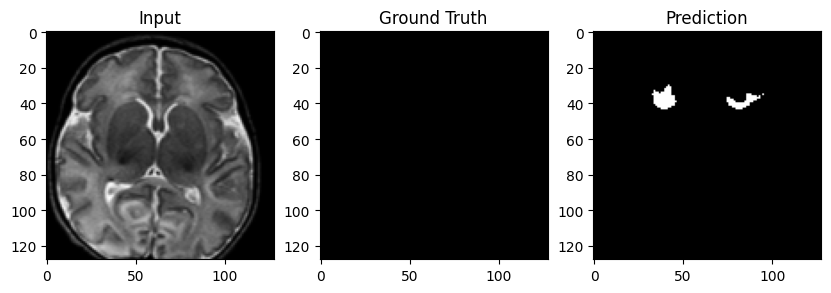

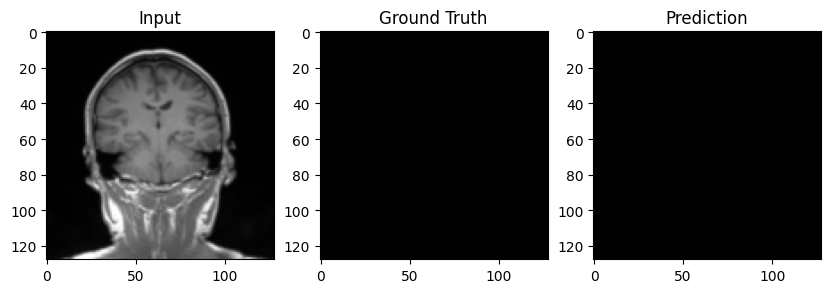

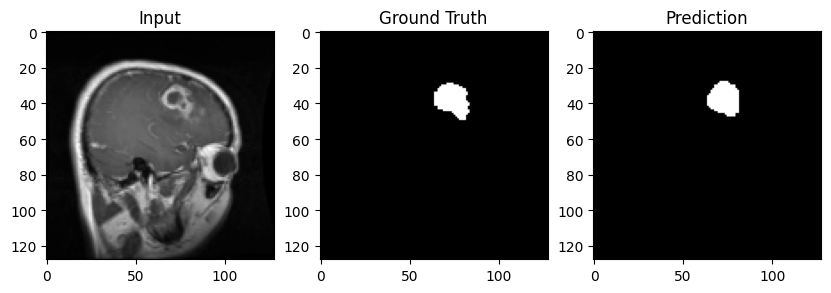

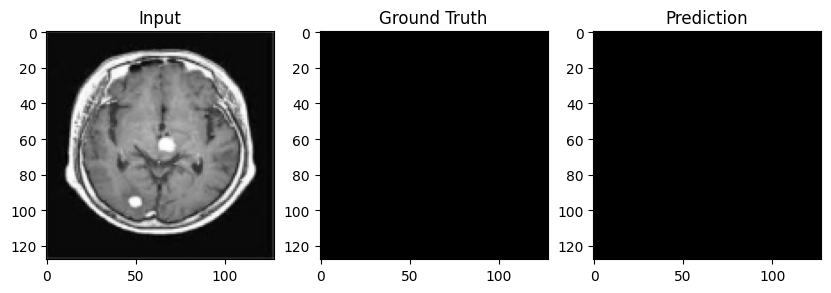

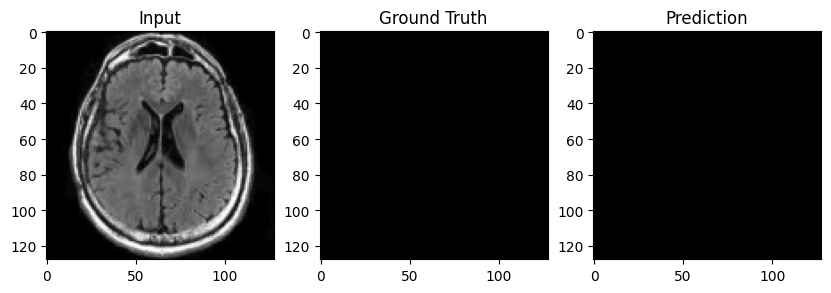

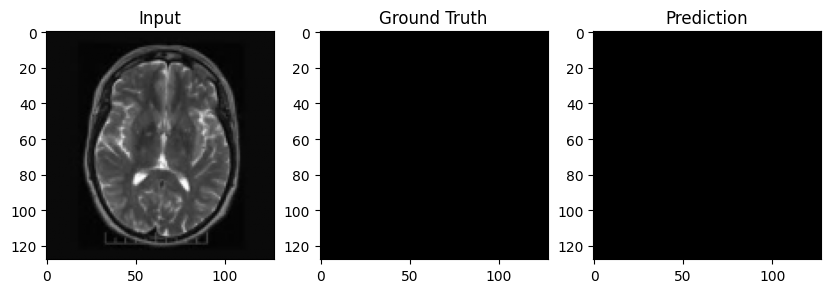

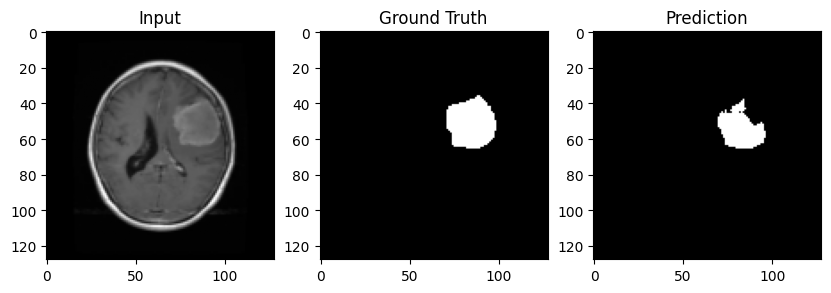

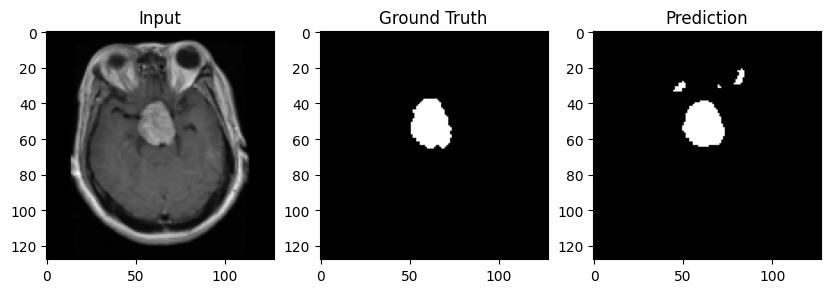

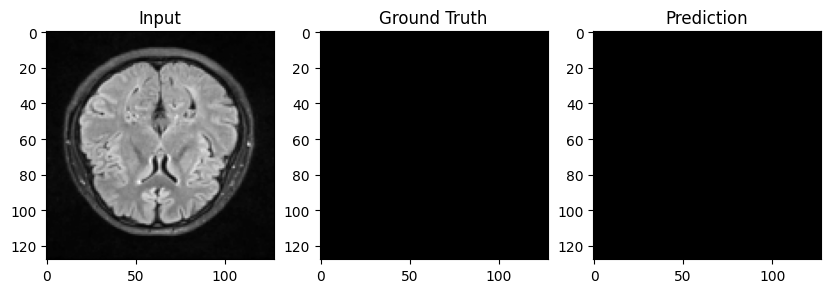

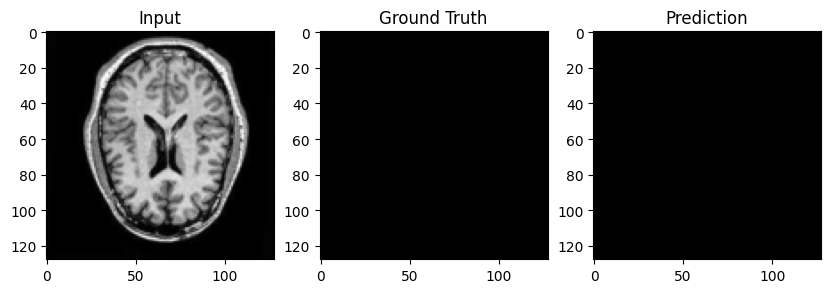

In [34]:
for i in range(10):
    visualize(model, val_dataset, idx=i)